In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sys
import os
package_dir = os.path.abspath(os.path.join(os.getcwd(), "..", "Modules"))
sys.path.append(package_dir)

from clean_dataframe.preprocessing import dtype16

Previous Notebook: `\Cleaning Scripts\2023-03-10 Additional Author Cleaning.ipynb`

In [2]:
# import papers_df
clean_path = r'G:\My Drive\BrainStation\BrainStationCapstone\Scripts and Notebooks\Cleaned Data'
clean_file = '2023-03-10 Additional Author Cleaning_papers_df.csv'
papers_df = pd.read_csv(os.path.join(clean_path, clean_file)).drop('Unnamed: 0', axis = 1)
papers_df = dtype16(papers_df, use_float=True, float_col= 'CitesPerYear')

In [3]:
papers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16297 entries, 0 to 16296
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Cites           16297 non-null  int16  
 1   Title           16297 non-null  object 
 2   Year            16297 non-null  int16  
 3   Source          16297 non-null  object 
 4   GSRank          16297 non-null  int16  
 5   ECC             16297 non-null  int16  
 6   CitesPerYear    16297 non-null  float16
 7   CitesPerAuthor  16297 non-null  int16  
 8   AuthorCount     16297 non-null  int16  
 9   query_id        16297 non-null  int16  
 10  first_auth      16297 non-null  object 
 11  second_auth     16297 non-null  object 
 12  third_auth      16297 non-null  object 
 13  ArticleType     16297 non-null  object 
 14  SJR             16297 non-null  int16  
 15  Hindex          16297 non-null  int16  
 16  SourceCountry   16297 non-null  object 
 17  SourceRegion    16297 non-null 

In [4]:
papers_df.head()

,Cites,Title,Year,Source,GSRank,ECC,CitesPerYear,CitesPerAuthor,AuthorCount,query_id,first_auth,second_auth,third_auth,ArticleType,SJR,Hindex,SourceCountry,SourceRegion,query_author
0,4186,low trapstate density and long carrier diffusi...,2015,science,1,4186,523.000,523,8,0,d shi,v adinolfi,r comin,journal,14,1229,United States,Northern America,eh sargent
1,1951,efficient and stable solutionprocessed planar ...,2017,science,4,1951,325.250,279,7,0,h tan,a jain,o voznyy,journal,14,1229,United States,Northern America,eh sargent
2,1756,homogeneously dispersed multimetal oxygenevolv...,2016,science,7,1756,250.875,251,7,0,bo zhang,x zheng,o voznyy,journal,14,1229,United States,Northern America,eh sargent
3,1343,co2 electroreduction to ethylene via hydroxide...,2018,science,11,1343,268.500,224,6,0,ct dinh,t burdyny,mg kibria,journal,14,1229,United States,Northern America,eh sargent
4,1168,what would it take for renewably powered elect...,2019,science,14,1168,292.000,195,6,0,p deluna,c hahn,d higgins,journal,14,1229,United States,Northern America,eh sargent


First, join the `papers_df` to the `query_df`

Need to find a way to cluster the individual authors

Need to expand the data set so that it has the form...


|Name |Title| ...|
|-----|--------|----|
|d shi|low trap-state density and| ...|
|v adinolfi	 |low trap-state density and| ...|
|r comin |low trap-state density and| ...|
|h tan	| efficient and stable solution-| ...|

In [5]:
def make_df(row):
    '''
    
    Parameters:
    ----------
    row: a Pandas Series that is a single row in the larger papers_df data frame. This row should contain
    information about the paper, including the columns 'first_auth', 'second_auth', 'third_auth'.
    
    Return:
    -------
    ret_df: a new data frame that has repeated information about each paper for each author. 
    It also has new columns 'AuthorName' and 'AuthorRank'
    
    '''
    
    # NumpPy Array of the author names
    auth_list = np.unique(row[['first_auth', 'second_auth', 'third_auth', 'query_author']].values)
    
    # Series of values exlcuding the first, second and third author columns
    new_ser = row.drop(['first_auth', 'second_auth', 'third_auth', 'query_author'])
    
    # Initiate a New Data Fame
    ret_df = pd.DataFrame()
    
    # Adding new rows to the data frame for each author in the paper
    for i in range(auth_list.shape[0]):
        auth_ser = pd.Series({'AuthorName': auth_list[i], 'AuthorRank': i+1})
        concat_ser = pd.concat([auth_ser, new_ser])
        
        concat_df = pd.DataFrame([concat_ser])
        ret_df = pd.concat([ret_df, concat_df], axis = 0)
    
    return ret_df

In [6]:
from tqdm.notebook import tqdm 

# Initiate DataFrame
new_df = pd.DataFrame()

# Adding new data frames (this takes about 4-5 minutes)
# Using a for loop instead of .apply() to be able to use the tqdm module to track the progress
for i in tqdm(range(papers_df.shape[0])):
    row = papers_df.loc[i, :]
    
    # Make a new set of dataframe
    ret_df = make_df(row)
     
    # Add to new df
    new_df = pd.concat([new_df, ret_df], axis = 0)

  0%|          | 0/16297 [00:00<?, ?it/s]

In [7]:
rows, cols = new_df.shape
print(f'The new_df has {rows} rows and {cols} columns')

The new_df has 58113 rows and 17 columns


In [8]:
new_df.sample(3)

,AuthorName,AuthorRank,Cites,Title,Year,Source,GSRank,ECC,CitesPerYear,CitesPerAuthor,AuthorCount,query_id,ArticleType,SJR,Hindex,SourceCountry,SourceRegion
0,d neher,2,101,ultrasensitive negative capacitance phototrans...,2020,nature communications,4,101,33.65625,10,10,150,journal,4,410,United Kingdom,Western Europe
0,l levina,4,428,efficient blue lightemitting diodes based on q...,2019,nature photonics,2,428,107.00000,43,11,440,journal,10,339,United Kingdom,Western Europe
0,s zhang,2,6,energy selects perovskite photovoltaics and st...,2019,acs energy letters,756,6,1.50000,1,5,0,journal,7,134,United States,Northern America


Now that we have the new data frame, we can more easily build a profile for each author.

In [9]:
num_df = new_df.groupby('AuthorName').size().reset_index(name='NumPapers_inDataset')
num_df

,AuthorName,NumPapers_inDataset
0,a aatiq,2
1,a abate,153
2,a abbas,2
3,a abbasi,1
4,a abdollahi,1
...,...,...
14160,zy xia,1
14161,zy xiao,1
14162,zy zhan,1
14163,zz dai,3


Want to see which statistic gives the the best distribution for the numeric columns.

In [10]:
new_df

,AuthorName,AuthorRank,Cites,Title,Year,Source,GSRank,ECC,CitesPerYear,CitesPerAuthor,AuthorCount,query_id,ArticleType,SJR,Hindex,SourceCountry,SourceRegion
0,d shi,1,4186,low trapstate density and long carrier diffusi...,2015,science,1,4186,523.000000,523,8,0,journal,14,1229,United States,Northern America
0,eh sargent,2,4186,low trapstate density and long carrier diffusi...,2015,science,1,4186,523.000000,523,8,0,journal,14,1229,United States,Northern America
0,r comin,3,4186,low trapstate density and long carrier diffusi...,2015,science,1,4186,523.000000,523,8,0,journal,14,1229,United States,Northern America
0,v adinolfi,4,4186,low trapstate density and long carrier diffusi...,2015,science,1,4186,523.000000,523,8,0,journal,14,1229,United States,Northern America
0,a jain,1,1951,efficient and stable solutionprocessed planar ...,2017,science,4,1951,325.250000,279,7,0,journal,14,1229,United States,Northern America
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,t sonsalla,2,34,rapid biodegradation of renewable polyurethane...,2020,bioresource technology reports,2,34,11.328125,6,6,578,journal,0,27,United Kingdom,Western Europe
0,wj meng,3,34,rapid biodegradation of renewable polyurethane...,2020,bioresource technology reports,2,34,11.328125,6,6,578,journal,0,27,United Kingdom,Western Europe
0,ad radadia,1,26,pitchrotational manipulation of single cells a...,2020,biomedical optics express,1,26,8.671875,3,8,582,journal,1,93,United States,Northern America
0,al moore,2,26,pitchrotational manipulation of single cells a...,2020,biomedical optics express,1,26,8.671875,3,8,582,journal,1,93,United States,Northern America


In [11]:
sub_df = new_df.drop(['Title', 'Source', 'Year','query_id', 'ArticleType', 'SourceCountry', 'SourceRegion'], axis = 1)
sub_df

,AuthorName,AuthorRank,Cites,GSRank,ECC,CitesPerYear,CitesPerAuthor,AuthorCount,SJR,Hindex
0,d shi,1,4186,1,4186,523.000000,523,8,14,1229
0,eh sargent,2,4186,1,4186,523.000000,523,8,14,1229
0,r comin,3,4186,1,4186,523.000000,523,8,14,1229
0,v adinolfi,4,4186,1,4186,523.000000,523,8,14,1229
0,a jain,1,1951,4,1951,325.250000,279,7,14,1229
...,...,...,...,...,...,...,...,...,...,...
0,t sonsalla,2,34,2,34,11.328125,6,6,0,27
0,wj meng,3,34,2,34,11.328125,6,6,0,27
0,ad radadia,1,26,1,26,8.671875,3,8,1,93
0,al moore,2,26,1,26,8.671875,3,8,1,93


Start with the Means of each numeric column

In [12]:
sub_df.groupby('AuthorName').agg(['mean', 'count', 'sum'])

AuthorRank                  Cites                    GSRank        \
                  mean count  sum        mean count     sum        mean count   
AuthorName                                                                      
a aatiq            1.0     2    2    3.000000     2     6.0   22.500000     2   
a abate            1.0   153  153   45.163399   153  6910.0   52.627451   153   
a abbas            1.0     2    2    7.000000     2    14.0  139.000000     2   
a abbasi           1.0     1    1   10.000000     1    10.0    8.000000     1   
a abdollahi        1.0     1    1  133.000000     1   133.0    7.000000     1   
...                ...   ...  ...         ...   ...     ...         ...   ...   
zy xia             4.0     1    4    4.000000     1     4.0   47.000000     1   
zy xiao            4.0     1    4   75.000000     1    75.0  331.000000     1   
zy zhan            4.0     1    4   25.000000     1    25.0   23.000000     1   
zz dai             4.0     3   12   57.000000     3   171.0   77.666667     3   
zz ma              4.0     1    4   22.000000     1    22.0   17.000000     1   

                            ECC  ... CitesPerAuthor AuthorCount             \
                sum        mean  ...            sum        mean count  sum   
AuthorName                       ...                                         
a aatiq        45.0    3.000000  ...              2    3.000000     2    6   
a abate      8052.0   45.163399  ...           1522    5.810458   153  889   
a abbas       278.0    7.000000  ...              3    5.500000     2   11   
a abbasi        8.0   10.000000  ...              2    6.000000     1    6   
a abdollahi     7.0  133.000000  ...             15    9.000000     1    9   
...             ...         ...  ...            ...         ...   ...  ...   
zy xia         47.0    4.000000  ...              0   10.000000     1   10   
zy xiao       331.0   75.000000  ...              9    8.000000     1    8   
zy zhan        23.0   25.000000  ...              4    6.000000     1    6   
zz dai        233.0   57.000000  ...             27    7.000000     3   21   
zz ma          17.0   22.000000  ...              2    9.000000     1    9   

                  SJR                 Hindex                 
                 mean count  sum        mean count      sum  
AuthorName                                                   
a aatiq      0.000000     2    0   86.500000     2    173.0  
a abate      1.084967   153  166  449.477124   153  68770.0  
a abbas      0.000000     2    0   80.000000     2    160.0  
a abbasi     0.000000     1    0   15.000000     1     15.0  
a abdollahi  3.000000     1    3  511.000000     1    511.0  
...               ...   ...  ...         ...   ...      ...  
zy xia       0.000000     1    0   71.000000     1     71.0  
zy xiao      8.000000     1    8  563.000000     1    563.0  
zy zhan      4.000000     1    4  413.000000     1    413.0  
zz dai       6.000000     3   18  227.000000     3    681.0  
zz ma        4.000000     1    4  200.000000     1    200.0  

[14165 rows x 27 columns]

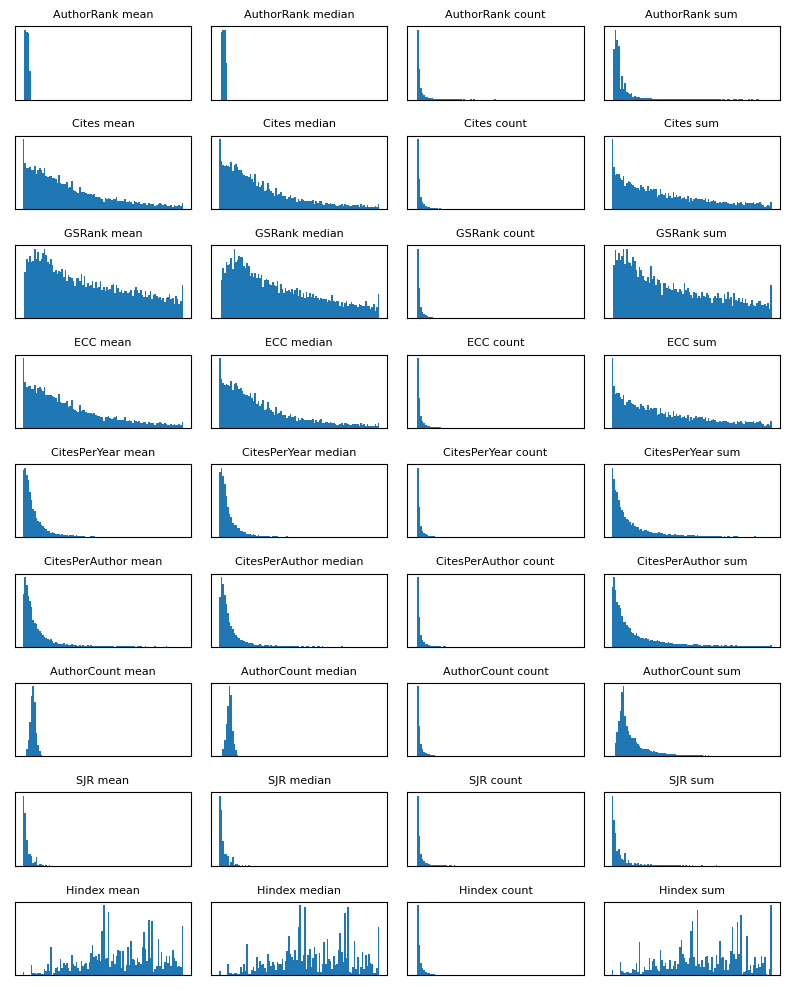

In [13]:
grouped_df = sub_df.groupby('AuthorName').agg(['mean', 'median', 'count', 'sum'])

level1_cols = sub_df.columns[1:]
level2_cols = ['mean', 'median', 'count', 'sum']

fig = plt.figure(figsize = (8, 10))
axes = fig.subplots(len(level1_cols), len(level2_cols))

i = 0 
for (row, col), ax in np.ndenumerate(axes):
    
    l1 = level1_cols[row]
    l2 = level2_cols[col]
    
    ax.hist(grouped_df[l1][l2], bins = 100, range = (0, 100))
    ax.set_title(f'{l1} {l2}', fontsize = 8)
    ax.set_xticks([],[])
    ax.set_yticks([],[])
    
    i += 1
    
fig.tight_layout()

It looks like, for the most part, the mean and median of each feature has a similar right-skew distribution as count and sum. The exceptions are `AuthorCount` and `AuthorRank` which have a move 'normal' distribution for the mean and median, and `Hindex` which has a more uniform distribution for mean, median and sum, but not count. For those reasons, for the final grouped dataset, let's chose to append the mean of the features for each author.

In [14]:
# Define new columns for the dataset
new_cols = np.asarray(['_'.join(['Mean', i]) for i in sub_df.groupby('AuthorName').mean().columns])
new_cols = ['AuthorName'] + np.where(new_cols == 'Mean_Hindex', 'Mean_SourceHindex', new_cols).tolist()

# Initiate new data frame
new_df2 = sub_df.groupby('AuthorName').mean().reset_index()

# Reset the columns names
new_df2.columns = new_cols

# Concat the Num column as well
new_df2 = pd.concat([new_df2, num_df.drop('AuthorName', axis= 1)], axis = 1)

new_df2.head()

,AuthorName,Mean_AuthorRank,Mean_Cites,Mean_GSRank,Mean_ECC,Mean_CitesPerYear,Mean_CitesPerAuthor,Mean_AuthorCount,Mean_SJR,Mean_SourceHindex,NumPapers_inDataset
0,a aatiq,1.0,3.000000,22.500000,3.000000,0.620117,1.000000,3.000000,0.000000,86.500000,2
1,a abate,1.0,45.163399,52.627451,45.163399,3.488281,9.947712,5.810458,1.084967,449.477124,153
2,a abbas,1.0,7.000000,139.000000,7.000000,2.335938,1.500000,5.500000,0.000000,80.000000,2
3,a abbasi,1.0,10.000000,8.000000,10.000000,5.000000,2.000000,6.000000,0.000000,15.000000,1
4,a abdollahi,1.0,133.000000,7.000000,133.000000,14.781250,15.000000,9.000000,3.000000,511.000000,1


We now have a beginning data set for machine learning, hurray! Let's check to see if there are any collinearities between the numerical columns in the data set.

<AxesSubplot:>

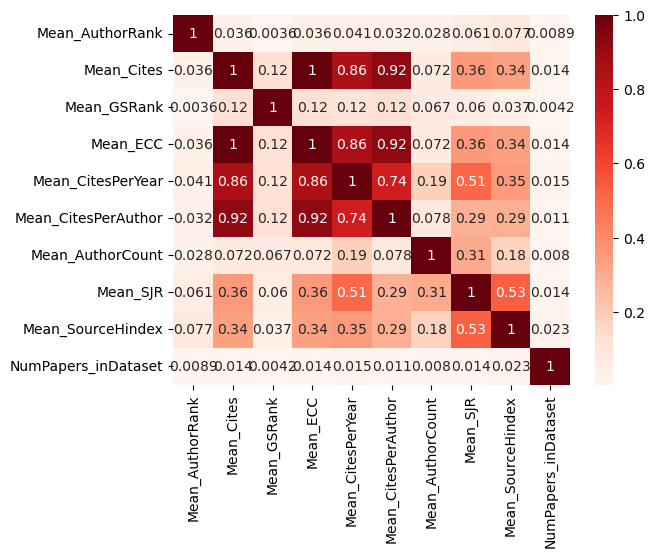

In [59]:
sns.heatmap(np.abs(new_df2.corr()), cmap = 'Reds', annot = True)

It looks like `Mean_SJR` and `Mean_SourceHindex` have a high collinearity. Since they essentially try to measure the same thing (the impact of the paper), let's remove `Mean_SJR` since its a more relative measurement compared to `Mean_SourceHindex`.

In [16]:
new_df3 = new_df2.drop('Mean_SJR', axis = 1)
new_df3.head(3)

,AuthorName,Mean_AuthorRank,Mean_Cites,Mean_GSRank,Mean_ECC,Mean_CitesPerYear,Mean_CitesPerAuthor,Mean_AuthorCount,Mean_SourceHindex,NumPapers_inDataset
0,a aatiq,1.0,3.000000,22.500000,3.000000,0.620117,1.000000,3.000000,86.500000,2
1,a abate,1.0,45.163399,52.627451,45.163399,3.488281,9.947712,5.810458,449.477124,153
2,a abbas,1.0,7.000000,139.000000,7.000000,2.335938,1.500000,5.500000,80.000000,2


<AxesSubplot:>

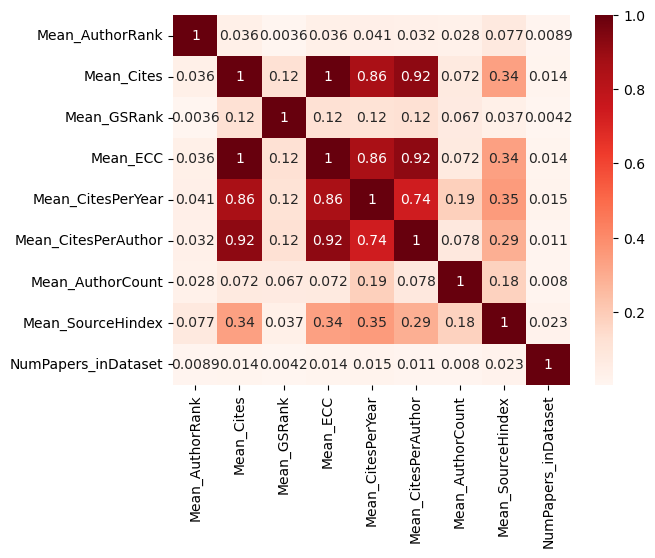

In [17]:
sns.heatmap(np.abs(new_df3.corr()), cmap = 'Reds', annot = True)

`Mean_CitesPerYear`, `Mean_CitesPerAuthor`, `Mean_ECC` and `Mean_Cites` also look to have a strong correlation. This makes sense since they're essentially measuring the same thing, so they might be redundant. Let's remove all the columns except `Mean_Cites`.

In [18]:
new_df4 = new_df3.drop(['Mean_CitesPerYear', 'Mean_CitesPerAuthor', 'Mean_ECC'], axis = 1)
new_df4.head(3)

,AuthorName,Mean_AuthorRank,Mean_Cites,Mean_GSRank,Mean_AuthorCount,Mean_SourceHindex,NumPapers_inDataset
0,a aatiq,1.0,3.000000,22.500000,3.000000,86.500000,2
1,a abate,1.0,45.163399,52.627451,5.810458,449.477124,153
2,a abbas,1.0,7.000000,139.000000,5.500000,80.000000,2


<AxesSubplot:>

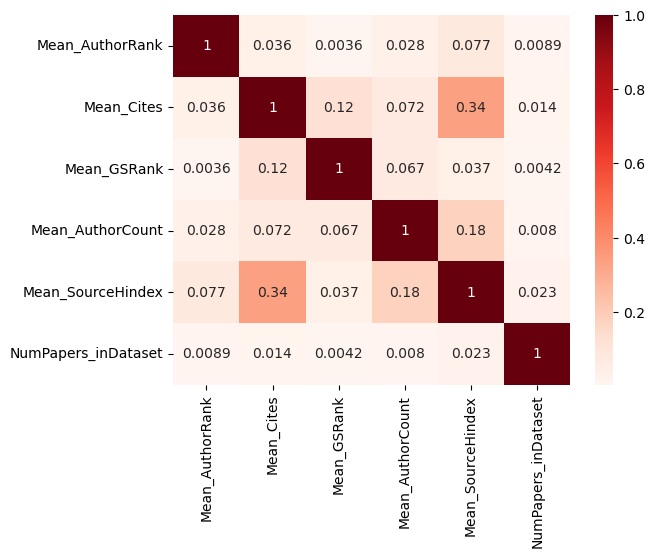

In [19]:
sns.heatmap(np.abs(new_df4.corr()), cmap = 'Reds', annot = True)

The only remaining columns with a correlation are `Mean_SourceHindex` and `Mean_Citations`.

In place of `Mean_Citations`, let's calculate the H index for each author to add to the data frame.

In [30]:
def calculate_hindex(group):
    
    # An arr of the citations
    citations = group['Cites'].values.tolist()
    
    n = len(citations)
    citations.sort(reverse=True)
    h_index = 0
    
    for i in range(n):
        if citations[i] >= i+1:
            h_index = i+1
        else:
            break
    
    return h_index

In [41]:
grouped_df = new_df.groupby('AuthorName')

# Get series of h index values
hindex_ser = grouped_df.apply(calculate_hindex).astype('int16').reset_index(name = 'Author_Hindex')

In [46]:
hindex_ser.sample(5)

,AuthorName,Author_Hindex
13603,y bisht,2
2326,c vandenbosch,1
360,a gopakumar,2
10820,rj anthony,2
6506,k arlauskas,1


Let's add `Author_Hindex` to the data frame

In [51]:
new_df5 = pd.concat([new_df4, pd.DataFrame(hindex_ser).drop('AuthorName', axis = 1)], axis = 1)

In [54]:
new_df5.sort_values('Author_Hindex')

,AuthorName,Mean_AuthorRank,Mean_Cites,Mean_GSRank,Mean_AuthorCount,Mean_SourceHindex,NumPapers_inDataset,Author_Hindex
7082,l costa,3.000000,0.000000,8.000000,9.000000,35.000000,2,0
1141,af vitoreti,2.000000,0.000000,244.000000,3.000000,460.000000,1,0
11981,sh aung,4.000000,0.000000,69.000000,6.000000,129.000000,1,0
11974,sg krishnan,3.000000,0.000000,26.000000,4.000000,166.000000,1,0
6962,kpp khirade,2.000000,0.000000,170.000000,4.000000,84.000000,1,0
...,...,...,...,...,...,...,...,...
3873,f gao,1.333333,195.898990,105.808081,6.671717,506.101010,198,91
12847,tz wu,2.980159,115.265873,165.158730,7.051587,478.785714,252,96
3127,dg lidzey,1.680365,182.885845,108.164384,6.726027,444.356164,219,97
2870,d neher,1.461538,176.659919,74.554656,7.194332,549.651822,247,114


Now let's double check the correlations

<AxesSubplot:>

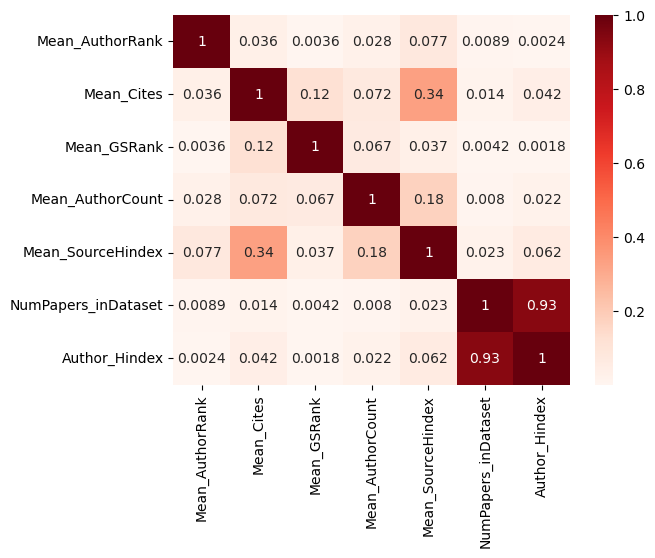

In [55]:
sns.heatmap(np.abs(new_df5.corr()), cmap = 'Reds', annot = True)

It looks like there is a somewhat-strong correlation between `Mean_SourceHindex` and `Mean_Cites`. Those both could contain value information, so let's leave them in for now. On the other hand, it looks like there is a strong correlation between `Author_Hindex` and `NumPapers_inDataset`. Let's take a look more closely.

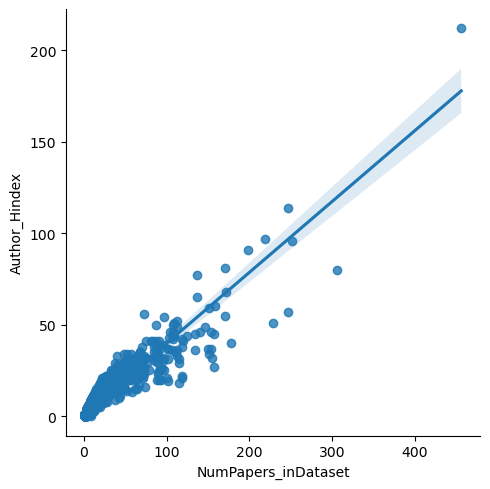

In [56]:
sns.lmplot(data = new_df5, x = 'NumPapers_inDataset', y = 'Author_Hindex')

It looks like there is a positive linear correlation between the two columns, suggesting that authors that have more papers in the data set will have a higher h index. To help avoid multicollinearity, let's drop `NumPapers_inDataset` since `Author_Hindex` is thought to provide more robust information about the 'influence' of the author.

In [57]:
new_df6 = new_df5.drop('NumPapers_inDataset', axis = 1)

In [58]:
new_df6.sample(3)

,AuthorName,Mean_AuthorRank,Mean_Cites,Mean_GSRank,Mean_AuthorCount,Mean_SourceHindex,Author_Hindex
3720,em gaigneaux,3.5,26.0,135.0,5.5,174.0,2
12016,simpson,4.0,36.0,23.0,5.0,242.0,1
8539,ma faridi,1.0,1.0,45.0,6.0,19.0,1


<AxesSubplot:>

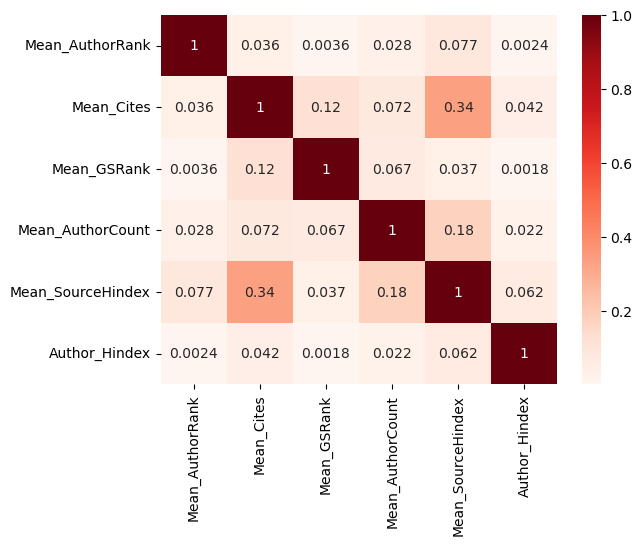

In [61]:
sns.heatmap(np.abs(new_df6.corr()), cmap = 'Reds', annot = True)

Correlations look good for now!

Next, let's use `OneHotEncode` to generate columns for if each author is published in a specific journal or not. The encoded values will be stored in `encoded_df`

In [65]:
from sklearn.preprocessing import OneHotEncoder

# Instantiate the OneHotEncoder
ohe = OneHotEncoder()

# Fit the OneHotEncoder to the subcategory column and transform
# It expects a 2D array, so we first convert the column into a DataFrame
subcategory = pd.DataFrame(new_df['Source'])
encoded = ohe.fit_transform(subcategory)

# Convert from sparse matrix to dense
dense_array = encoded.toarray()

# Define new Columns for the encoded array 
cols = ['In_' + i for i in ohe.categories_]

# Put into a dataframe to get column names
encoded_df = pd.DataFrame(dense_array, columns=cols, dtype=int)

# Show
encoded_df.head()

,In_2d materials,In_accounts of chemical research,In_acs applied bio materials,In_acs applied electronic materials,In_acs applied energy materials,In_acs applied materials & interfaces,In_acs applied nano materials,In_acs applied polymer materials,In_acs biomaterials science and engineering,In_acs catalysis,...,In_ukrainian journal of physical optics,In_ultramicroscopy,In_ultrasonics sonochemistry,In_vacuum,In_vakuum in forschung und praxis,In_water research,In_wiley interdisciplinary reviews computational molecular science,In_world journal of engineering,In_wuli xuebao/acta physica sinica,In_zeitschrift fur naturforschung section b journal of chemical sciences
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Let's check for any collinearites in the `encoded_df`

([], [])

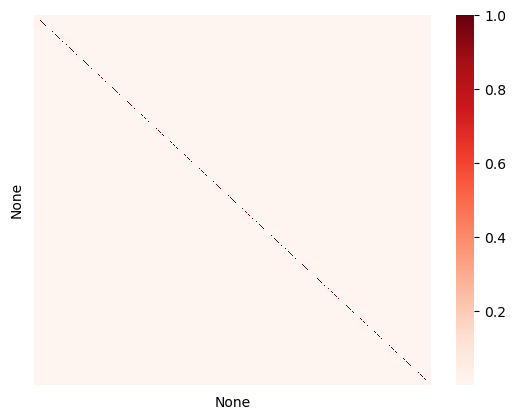

In [71]:
sns.heatmap(np.abs(encoded_df.corr()), cmap = 'Reds')
plt.xticks([],[])
plt.yticks([],[])

Hurray! It doesn't look like there are any collinearities. Let's join `encoded_df` to the `new_df` in the new `encodeSource_df` 

In [89]:
# fix formatting issues with the columns
encoded_df.columns, = ['In_' + i for i in ohe.categories_] 

encodeSource_df = pd.concat([new_df.loc[:, 'AuthorName'].reset_index(drop = True), encoded_df.reset_index(drop = True)], axis = 1)

In [90]:
encodeSource_df.sample(5)

,AuthorName,In_2d materials,In_accounts of chemical research,In_acs applied bio materials,In_acs applied electronic materials,In_acs applied energy materials,In_acs applied materials & interfaces,In_acs applied nano materials,In_acs applied polymer materials,In_acs biomaterials science and engineering,...,In_ukrainian journal of physical optics,In_ultramicroscopy,In_ultrasonics sonochemistry,In_vacuum,In_vakuum in forschung und praxis,In_water research,In_wiley interdisciplinary reviews computational molecular science,In_world journal of engineering,In_wuli xuebao/acta physica sinica,In_zeitschrift fur naturforschung section b journal of chemical sciences
13924,mk jo,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
48721,m isshiki,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14862,dt moore,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
34824,a soosaimanickam,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
33434,a todinova,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Now let's group by `AuthorName` and aggregate the encoded columns by sum (so each column will have a sum of times an author is in a journal)

In [106]:
encodeSource_df.groupby('AuthorName').sum()

,In_2d materials,In_accounts of chemical research,In_acs applied bio materials,In_acs applied electronic materials,In_acs applied energy materials,In_acs applied materials & interfaces,In_acs applied nano materials,In_acs applied polymer materials,In_acs biomaterials science and engineering,In_acs catalysis,...,In_ukrainian journal of physical optics,In_ultramicroscopy,In_ultrasonics sonochemistry,In_vacuum,In_vakuum in forschung und praxis,In_water research,In_wiley interdisciplinary reviews computational molecular science,In_world journal of engineering,In_wuli xuebao/acta physica sinica,In_zeitschrift fur naturforschung section b journal of chemical sciences
AuthorName,,,,,,,,,,,,,,,,,,,,,
a aatiq,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
a abate,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
a abbas,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
a abbasi,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
a abdollahi,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zy xia,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
zy xiao,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
zy zhan,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Example slice of `In_journal of physical chemistry c`

In [98]:
encodeSource_df.groupby('AuthorName')['In_journal of physical chemistry c'].sum().sort_values()

AuthorName
a aatiq           0
n shinotsuka      0
n shirahata       0
n shirato         0
n sial            0
               ... 
ab tarasov       57
sv yakunin       64
di wu            73
j wongleung      89
mp ghimire      113
Name: In_journal of physical chemistry c, Length: 14165, dtype: int32

In [109]:
new_df7 = pd.concat([new_df6.reset_index(drop = True), encodeSource_df.groupby('AuthorName').sum().reset_index(drop = True)], axis = 1)

In [112]:
new_df7.sample(5)

,AuthorName,Mean_AuthorRank,Mean_Cites,Mean_GSRank,Mean_AuthorCount,Mean_SourceHindex,Author_Hindex,In_2d materials,In_accounts of chemical research,In_acs applied bio materials,...,In_ukrainian journal of physical optics,In_ultramicroscopy,In_ultrasonics sonochemistry,In_vacuum,In_vakuum in forschung und praxis,In_water research,In_wiley interdisciplinary reviews computational molecular science,In_world journal of engineering,In_wuli xuebao/acta physica sinica,In_zeitschrift fur naturforschung section b journal of chemical sciences
7853,m gonzlez,2.0,19.000000,105.000000,6.000000,78.0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1514,b ahrens,1.0,48.000000,84.000000,7.000000,255.0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1356,ao alvarez,1.0,88.000000,91.000000,8.000000,376.0,2,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6531,k burns,3.0,3.000000,47.000000,10.000000,103.0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5112,hs xu,1.0,32.666667,49.666667,7.666667,104.0,2,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Let's check for any collinearities.

In [113]:
corr_matrix = new_df7.corr()
corr_matrix

,Mean_AuthorRank,Mean_Cites,Mean_GSRank,Mean_AuthorCount,Mean_SourceHindex,Author_Hindex,In_2d materials,In_accounts of chemical research,In_acs applied bio materials,In_acs applied electronic materials,...,In_ukrainian journal of physical optics,In_ultramicroscopy,In_ultrasonics sonochemistry,In_vacuum,In_vakuum in forschung und praxis,In_water research,In_wiley interdisciplinary reviews computational molecular science,In_world journal of engineering,In_wuli xuebao/acta physica sinica,In_zeitschrift fur naturforschung section b journal of chemical sciences
Mean_AuthorRank,1.000000,0.036223,0.003599,0.028395,0.076589,-0.002367,-0.004310,0.003874,-0.006335,-0.000958,...,-0.005579,0.002875,-0.001877,-0.001014,0.005678,-0.007985,0.000949,-0.000350,-0.000315,0.000204
Mean_Cites,0.036223,1.000000,-0.122479,0.072436,0.336702,0.041526,-0.004413,0.003190,-0.006885,-0.007241,...,-0.005515,0.000101,-0.004594,-0.006858,-0.004531,-0.002285,-0.007573,-0.008817,-0.006039,-0.012088
Mean_GSRank,0.003599,-0.122479,1.000000,0.067262,0.036796,-0.001829,-0.004621,0.002557,0.002733,0.008754,...,-0.003683,0.003261,-0.011231,-0.003552,0.013346,-0.011523,-0.007688,-0.005531,0.000301,-0.008684
Mean_AuthorCount,0.028395,0.072436,0.067262,1.000000,0.176488,0.021808,0.007452,-0.006558,-0.001742,0.001798,...,-0.006249,-0.000340,-0.009739,-0.004252,-0.013258,0.003783,-0.021888,-0.003973,-0.005862,-0.049795
Mean_SourceHindex,0.076589,0.336702,0.036796,0.176488,1.000000,0.062111,-0.021949,0.006515,-0.024463,-0.021138,...,-0.011262,-0.009837,-0.014549,-0.026076,-0.014455,-0.003865,-0.023318,-0.030282,-0.018738,-0.036647
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
In_water research,-0.007985,-0.002285,-0.011523,0.003783,-0.003865,-0.000288,-0.000394,-0.000373,-0.000288,-0.000383,...,-0.000212,-0.000253,-0.000212,-0.000342,-0.000245,1.000000,-0.000306,-0.000372,-0.000245,-0.000437
In_wiley interdisciplinary reviews computational molecular science,0.000949,-0.007573,-0.007688,-0.021888,-0.023318,0.023631,-0.000569,-0.000538,-0.000416,-0.000553,...,-0.000306,-0.000365,-0.000306,-0.000494,-0.000353,-0.000306,1.000000,-0.000537,-0.000353,-0.000631
In_world journal of engineering,-0.000350,-0.008817,-0.005531,-0.003973,-0.030282,0.015162,0.010287,-0.000655,-0.000506,-0.000674,...,-0.000372,-0.000444,-0.000372,-0.000601,-0.000430,-0.000372,-0.000537,1.000000,-0.000430,-0.000768
In_wuli xuebao/acta physica sinica,-0.000315,-0.006039,0.000301,-0.005862,-0.018738,0.018079,-0.000455,-0.000430,-0.000332,-0.000443,...,-0.000245,-0.000292,-0.000245,-0.000395,-0.000282,-0.000245,-0.000353,-0.000430,1.000000,-0.000505


In [122]:
cols = new_df7.columns

for (row, col), val in np.ndenumerate(corr_matrix):
    
    if val > 0.4 and val != 1:
        print(cols[row], cols[col], val)

Mean_SourceHindex In_nature chemistry 0.42134093758604296
Author_Hindex In_annual review of physical chemistry 0.8781994643619223
Author_Hindex In_optoelectronics letters 0.5789516330826028
In_2d materials In_advanced quantum technologies 0.7526261234254039
In_accounts of chemical research In_applied magnetic resonance 0.8311664200423059
In_accounts of chemical research In_bulletin of the korean chemical society 0.5660213487440852
In_accounts of chemical research In_bulletin of the lebedev physics institute 0.920082575512763
In_accounts of chemical research In_chinese optics letters 0.8660789376272026
In_accounts of chemical research In_clean technologies and environmental policy 0.7470544851392691
In_accounts of chemical research In_energy storage materials 0.8683529346682637
In_accounts of chemical research In_inorganic chemistry communication 0.7906039957370895
In_accounts of chemical research In_international journal of modern physics b 0.72832188602263
In_accounts of chemical rese

In_physics and chemistry of solid state In_microsystem technologies 0.49985876703622534
In_physics education In_physical chemistry chemical physics 0.5669948998013629
In_physics education In_physical review b 0.6170764063629633
In_physics letters, section a general, atomic and solid state physics In_journal of the national science foundation of sri lanka 0.4385132996131353
In_physics letters, section a general, atomic and solid state physics In_scientific reports 0.6276249083000223
In_physics of the solid state In_integrated ferroelectrics 0.4080969411536048
In_physics of the solid state In_micro and nano engineering 0.4080969411536048
In_physics of the solid state In_revista cubana de fisica 0.40806088809590935
In_physics of the solid state In_surface science 0.4669347315756249
In_physics reports In_journal of materials science materials in medicine 0.7212653586950426
In_physics reports In_materials research express 0.49493331163431586
In_plasma chemistry and plasma processing In_acco

<AxesSubplot:>

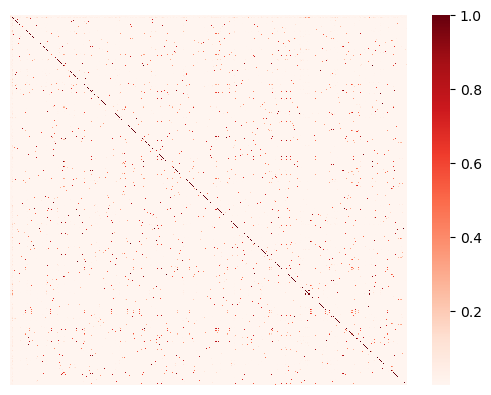

In [120]:
sns.heatmap(np.abs(corr_matrix), xticklabels= False, yticklabels=False, cmap = 'Reds')

There looks like there are some spots of strong colliarities, mostlt between the journal encoders. However, since the goal is to build a reccomender system, we shouldn't have to worry about collinearities between endcoded journals. Let's keep them in for now and we can do back to them if necessary.

Let's save `new_df` as 'expanded_df' and `new_df7` as 'grouped_df'

In [126]:
clean_path = r'G:\My Drive\BrainStation\BrainStationCapstone\Scripts and Notebooks\Cleaned Data'
clean_file = '2023-03-10 Expanding the papers_df_expanded_df.csv'
new_df.to_csv(os.path.join(clean_path, clean_file), index = False)

In [127]:
clean_path = r'G:\My Drive\BrainStation\BrainStationCapstone\Scripts and Notebooks\Cleaned Data'
clean_file = '2023-03-10 Expanding the papers_df_grouped_df.csv'
new_df7.to_csv(os.path.join(clean_path, clean_file), index = False)

---